# Packages

In [1]:
%pip install sklearn
%pip install pandas
%pip install numpy
%pip install xgboost
%pip install matplotlib
%pip install seaborn
%pip install xgboost
%pip install cleanlab
%pip install ipywidgets
%pip install imbalanced-learn
%pip install statsmodels
%pip install shap
%pip install prophet
%pip install plotly
%pip install tensorflow
%pip install scipy
%pip install statsforecast
%pip install utilsforecast


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
    

# Imports

In [2]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cleanlab.filter import find_label_issues
from imblearn.under_sampling import RandomUnderSampler
from matplotlib import cm
from sklearn.cluster import KMeans
from sklearn.decomposition import (
    PCA,
    TruncatedSVD
)
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest, RandomForestClassifier, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    accuracy_score,
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    StratifiedKFold,
    TimeSeriesSplit,
    cross_val_predict,
    train_test_split
)
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
    Binarizer,
    FunctionTransformer,
    OneHotEncoder
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stl.mstl import MSTL
import shap
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, LSTM, Conv1D,
                                     GlobalMaxPooling1D, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from statsforecast.models import (
    AutoARIMA,
    Naive,
    HistoricAverage,
    WindowAverage,
    SeasonalNaive,
)
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *
import one_hot_encoder
from keras import Input
from utilsforecast.plotting import plot_series
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Functions

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#trigonometric-features

In [3]:
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))


def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

In [4]:
def sklearnEvaluate(model, X, y, cv, model_prop=None, model_step=None):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_estimator=model_prop is not None,
    )
    if model_prop is not None:
        if model_step is not None:
            values = [
                getattr(m[model_step], model_prop) for m in cv_results["estimator"]
            ]
        else:
            values = [getattr(m, model_prop) for m in cv_results["estimator"]]
        print(f"Mean model.{model_prop} = {np.mean(values)}")
    mae = -cv_results["test_neg_mean_absolute_error"]
    rmse = -cv_results["test_neg_root_mean_squared_error"]
    print(
        f"Mean Absolute Error:     {mae.mean():.3f} +/- {mae.std():.3f}\n"
        f"Root Mean Squared Error: {rmse.mean():.3f} +/- {rmse.std():.3f}"
    )

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tf_style_predictions(X_3D, y_3D, model, feature_index=0, num_plots=3):
    """
    Creates a stacked plot exactly like the TensorFlow Time Series tutorial.

    Parameters:
    X_3D: Your 3D testing features (Samples, Time_Steps, Features)
    y_3D: Your testing labels
    model: Your trained LSTM/CNN model
    feature_index: Which feature to draw the blue line for (e.g., 0 for PM2.5)
    num_plots: How many subplots to stack (the image has 3)
    """
    # 1. Get the model's predictions for the test set
    # Using > 0.5 to convert the probability back into a 1 or 0
    predictions = (model.predict(X_3D) > 0.5).astype(int)

    # 2. Set up the figure with multiple subplots stacked vertically
    fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 8))

    # 3. Loop through to draw a few random examples from your test set
    # (We multiply by 100 just to space out the examples we pick)
    for i, ax in enumerate(axes):
        sample_idx = i * 100

        # Extract the sequence of inputs for the blue line
        inputs = X_3D[sample_idx, :, feature_index]
        input_time_steps = list(range(len(inputs)))

        # The label/prediction happens at the time step immediately after the inputs
        target_time = len(inputs)
        label = y_3D[sample_idx]
        prediction = predictions[sample_idx][0]

        # --- DRAWING THE TF STYLE PLOT ---

        # Plot 1: The Inputs (Blue line with dots)
        ax.plot(input_time_steps, inputs, label='Inputs', marker='.', zorder=-10)

        # Plot 2: The True Label (Green Circle with black edge)
        ax.scatter(target_time, label, edgecolors='k', label='Labels',
                   c='#2ca02c', s=64, zorder=2)

        # Plot 3: The Prediction (Orange X with black edge)
        ax.scatter(target_time, prediction, marker='X', edgecolors='k',
                   label='Predictions', c='#ff7f0e', s=64, zorder=3)

        # Formatting to match the tutorial
        ax.set_ylabel('Scaled Feature')
        if i == 0:
            ax.legend() # Only put the legend on the top plot

    # Add the x-axis label only to the very bottom plot
    axes[-1].set_xlabel('Time [h]')

    plt.tight_layout()
    plt.show()

# How to use it:
# (Assuming your scaled PM2.5 is at index 0 of your features)
# plot_tf_style_predictions(X_test_3D, y_test_3D, lstm_model, feature_index=0, num_plots=3)

In [6]:
def max_missing_sequence(ser):
    # 1. Mask for null values
    is_null = ser.isnull()

    # 2. Group consecutive booleans
    # (True -> False or False -> True increments the group)
    groups = (is_null != is_null.shift()).astype(int).cumsum()

    # 3. Filter to only look at the 'True' (null) groups and count them
    null_counts = is_null[is_null].groupby(groups).size()

    # 4. Return the max, or 0 if no nulls exist
    return null_counts.max() if not null_counts.empty else 0


# Pipelines

In [7]:
KNNImputerPipe = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('classifier', RandomForestClassifier())
])

# Data Exploration

In [8]:
# Find all files that start with "PRSA_Data" and end with ".csv"
file_paths = glob.glob("./beijing+multi+site+air+quality+data/PRSA_Data_20130301-20170228/PRSA_Data_*Nongzhanguan*.csv")

# Read all into a list
dataframes = [pd.read_csv(file) for file in file_paths]

# Combine them all together into one giant dataset
df = pd.concat(dataframes, ignore_index=True)

df['wd'] = df['wd'].astype('category')
df['station'] = df['station'].astype('category')

df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['DayOfWeek'] = df['datetime'].dt.dayofweek

# Create a binary feature: 1 if it is Saturday (5) or Sunday (6), 0 if weekday
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Create a binary feature for "Rush Hour" (e.g., 7 AM to 9 AM, and 5 PM to 7 PM)
df['Is_Rush_Hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

categorical_columns = df.columns[df.dtypes == "category"]

one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cyclicTransformer = ColumnTransformer(
    transformers=[
        # ("categorical", one_hot_encoder, categorical_columns),
        ("month_sin", sin_transformer(12), ["month"]),
        ("month_cos", cos_transformer(12), ["month"]),
        ("weekday_sin", sin_transformer(7), ["DayOfWeek"]),
        ("weekday_cos", cos_transformer(7), ["DayOfWeek"]),
        ("hour_sin", sin_transformer(24), ["hour"]),
        ("hour_cos", cos_transformer(24), ["hour"]),
    ],
    remainder=MinMaxScaler(),
)

df['month_sin'] = np.sin(df['month'] / 12 * 2 * np.pi)
df['month_cos'] = np.cos(df['month'] / 12 * 2 * np.pi)
df['weekday_sin'] = np.sin(df['DayOfWeek'] / 7 * 2 * np.pi)
df['weekday_cos'] = np.cos(df['DayOfWeek'] / 7 * 2 * np.pi)
df['hour_sin'] = np.sin(df['hour'] / 24 * 2 * np.pi)
df['hour_cos'] = np.cos(df['hour'] / 24 * 2 * np.pi)

# Sort by station FIRST, then by time.
df = df.sort_values(by=['station', 'datetime']).reset_index(drop=True)
df = df.drop('No',axis=1)

df_all.to_csv("PRSA_Data_20130301-20170228.csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          35064 non-null  int64         
 1   month         35064 non-null  int64         
 2   day           35064 non-null  int64         
 3   hour          35064 non-null  int64         
 4   PM2.5         34436 non-null  float64       
 5   PM10          34624 non-null  float64       
 6   SO2           34618 non-null  float64       
 7   NO2           34372 non-null  float64       
 8   CO            33858 non-null  float64       
 9   O3            34558 non-null  float64       
 10  TEMP          35044 non-null  float64       
 11  PRES          35044 non-null  float64       
 12  DEWP          35044 non-null  float64       
 13  RAIN          35044 non-null  float64       
 14  wd            34986 non-null  category      
 15  WSPM          35050 non-null  float6

## Do we have missing data?

In [10]:
df.isnull().sum().sort_values(ascending=False)

CO              1206
NO2              692
PM2.5            628
O3               506
SO2              446
PM10             440
wd                78
TEMP              20
DEWP              20
PRES              20
RAIN              20
WSPM              14
Is_Weekend         0
weekday_cos        0
weekday_sin        0
hour_sin           0
month_cos          0
month_sin          0
Is_Rush_Hour       0
year               0
DayOfWeek          0
datetime           0
station            0
month              0
hour               0
day                0
hour_cos           0
dtype: int64

In [11]:
longest_gaps = df.apply(max_missing_sequence)
longest_gaps.sort_values(ascending=False)

CO              147
PM2.5            56
O3               55
PM10             55
SO2              55
NO2              55
TEMP              6
DEWP              6
PRES              6
RAIN              6
wd                5
WSPM              5
Is_Weekend        0
weekday_cos       0
hour_sin          0
weekday_sin       0
month_cos         0
month_sin         0
Is_Rush_Hour      0
year              0
DayOfWeek         0
datetime          0
station           0
month             0
hour              0
day               0
hour_cos          0
dtype: int64

In [12]:
station_reliability = df.isnull().sum(axis=1).groupby(df['station']).sum().sort_values()

print(station_reliability)

station
Nongzhanguan    4090
dtype: int64


In [13]:
# Calculate the percentage of missing values per station
missing_pct = df.groupby('station').apply(lambda x: x.isnull().mean().mean())

# Get the station with the minimum percentage
best_station_pct = missing_pct.idxmin()

print(f"The most reliable station (by percentage) is: {best_station_pct}")

The most reliable station (by percentage) is: Nongzhanguan


In [14]:
df_with_nans = df[df.isnull().any(axis=1)]
df_with_nans

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,...,datetime,DayOfWeek,Is_Weekend,Is_Rush_Hour,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
26,2013,3,2,2,3.0,9.0,NaN,38.0,400.0,52.0,...,2013-03-02 02:00:00,5,1,0,1.000000,6.123234e-17,-0.974928,-0.222521,0.500000,0.866025
27,2013,3,2,3,3.0,6.0,8.0,30.0,NaN,89.0,...,2013-03-02 03:00:00,5,1,0,1.000000,6.123234e-17,-0.974928,-0.222521,0.707107,0.707107
28,2013,3,2,4,3.0,6.0,7.0,NaN,400.0,59.0,...,2013-03-02 04:00:00,5,1,0,1.000000,6.123234e-17,-0.974928,-0.222521,0.866025,0.500000
122,2013,3,6,2,184.0,214.0,NaN,158.0,2399.0,35.0,...,2013-03-06 02:00:00,2,0,0,1.000000,6.123234e-17,0.974928,-0.222521,0.500000,0.866025
123,2013,3,6,3,169.0,190.0,107.0,155.0,NaN,35.0,...,2013-03-06 03:00:00,2,0,0,1.000000,6.123234e-17,0.974928,-0.222521,0.707107,0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35026,2017,2,27,10,NaN,NaN,NaN,NaN,NaN,NaN,...,2017-02-27 10:00:00,0,0,0,0.866025,5.000000e-01,0.000000,1.000000,0.500000,-0.866025
35029,2017,2,27,13,NaN,6.0,40.0,93.0,200.0,32.0,...,2017-02-27 13:00:00,0,0,0,0.866025,5.000000e-01,0.000000,1.000000,-0.258819,-0.965926
35042,2017,2,28,2,NaN,NaN,NaN,NaN,NaN,NaN,...,2017-02-28 02:00:00,1,0,0,0.866025,5.000000e-01,0.781831,0.623490,0.500000,0.866025
35054,2017,2,28,14,NaN,6.0,2.0,10.0,200.0,94.0,...,2017-02-28 14:00:00,1,0,0,0.866025,5.000000e-01,0.781831,0.623490,-0.500000,-0.866025


## Handling Missing Data - Forward-fill missing values

It's wrong to do this here

Forward fill and backward fill are methods used to handle missing values in time series data by propagating the last or next valid observation, respectively. These methods help maintain the continuity of observations in your dataset.

https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html#filling-missing-data
https://hatefdastour.github.io/notes/Introduction_to_Python_Programming/chapter_05/PyIntro_C05S07.html

df_all = (
    df_all
    .set_index('station')
    .groupby('station')
    .ffill()
    .bfill()
    .reset_index()
)

In [15]:
df.isnull().sum().sort_values(ascending=False)

CO              1206
NO2              692
PM2.5            628
O3               506
SO2              446
PM10             440
wd                78
TEMP              20
DEWP              20
PRES              20
RAIN              20
WSPM              14
Is_Weekend         0
weekday_cos        0
weekday_sin        0
hour_sin           0
month_cos          0
month_sin          0
Is_Rush_Hour       0
year               0
DayOfWeek          0
datetime           0
station            0
month              0
hour               0
day                0
hour_cos           0
dtype: int64

In [16]:
df.columns.to_list()

['year',
 'month',
 'day',
 'hour',
 'PM2.5',
 'PM10',
 'SO2',
 'NO2',
 'CO',
 'O3',
 'TEMP',
 'PRES',
 'DEWP',
 'RAIN',
 'wd',
 'WSPM',
 'station',
 'datetime',
 'DayOfWeek',
 'Is_Weekend',
 'Is_Rush_Hour',
 'month_sin',
 'month_cos',
 'weekday_sin',
 'weekday_cos',
 'hour_sin',
 'hour_cos']

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          35064 non-null  int64         
 1   month         35064 non-null  int64         
 2   day           35064 non-null  int64         
 3   hour          35064 non-null  int64         
 4   PM2.5         34436 non-null  float64       
 5   PM10          34624 non-null  float64       
 6   SO2           34618 non-null  float64       
 7   NO2           34372 non-null  float64       
 8   CO            33858 non-null  float64       
 9   O3            34558 non-null  float64       
 10  TEMP          35044 non-null  float64       
 11  PRES          35044 non-null  float64       
 12  DEWP          35044 non-null  float64       
 13  RAIN          35044 non-null  float64       
 14  wd            34986 non-null  category      
 15  WSPM          35050 non-null  float6

In [18]:
df.describe().transpose()


,count,mean,min,25%,50%,75%,max,std
year,35064.0,2014.66256,2013.0,2014.0,2015.0,2016.0,2017.0,1.177213
month,35064.0,6.52293,1.0,4.0,7.0,10.0,12.0,3.448752
day,35064.0,15.729637,1.0,8.0,16.0,23.0,31.0,8.800218
hour,35064.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922285
PM2.5,34436.0,84.838483,2.0,22.0,59.0,116.0,844.0,86.225344
PM10,34624.0,108.991096,2.0,38.0,85.0,149.0,995.0,95.341177
SO2,34618.0,18.689242,0.5712,3.0,9.0,23.0,257.0,24.280665
NO2,34372.0,58.097172,2.0,29.0,51.0,80.0,273.0,36.29774
CO,33858.0,1324.350198,100.0,500.0,900.0,1600.0,10000.0,1245.166124
O3,34558.0,58.534682,0.2142,10.0,45.0,84.0,390.0,58.401448


# Evolution of a features over time

In [19]:
features = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3','TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df_single_station = df # [df['station'] == 'Aotizhongxin'].copy()
df_daily = df_single_station.set_index("datetime")
df_daily = df_daily[features].resample('H').mean().dropna()

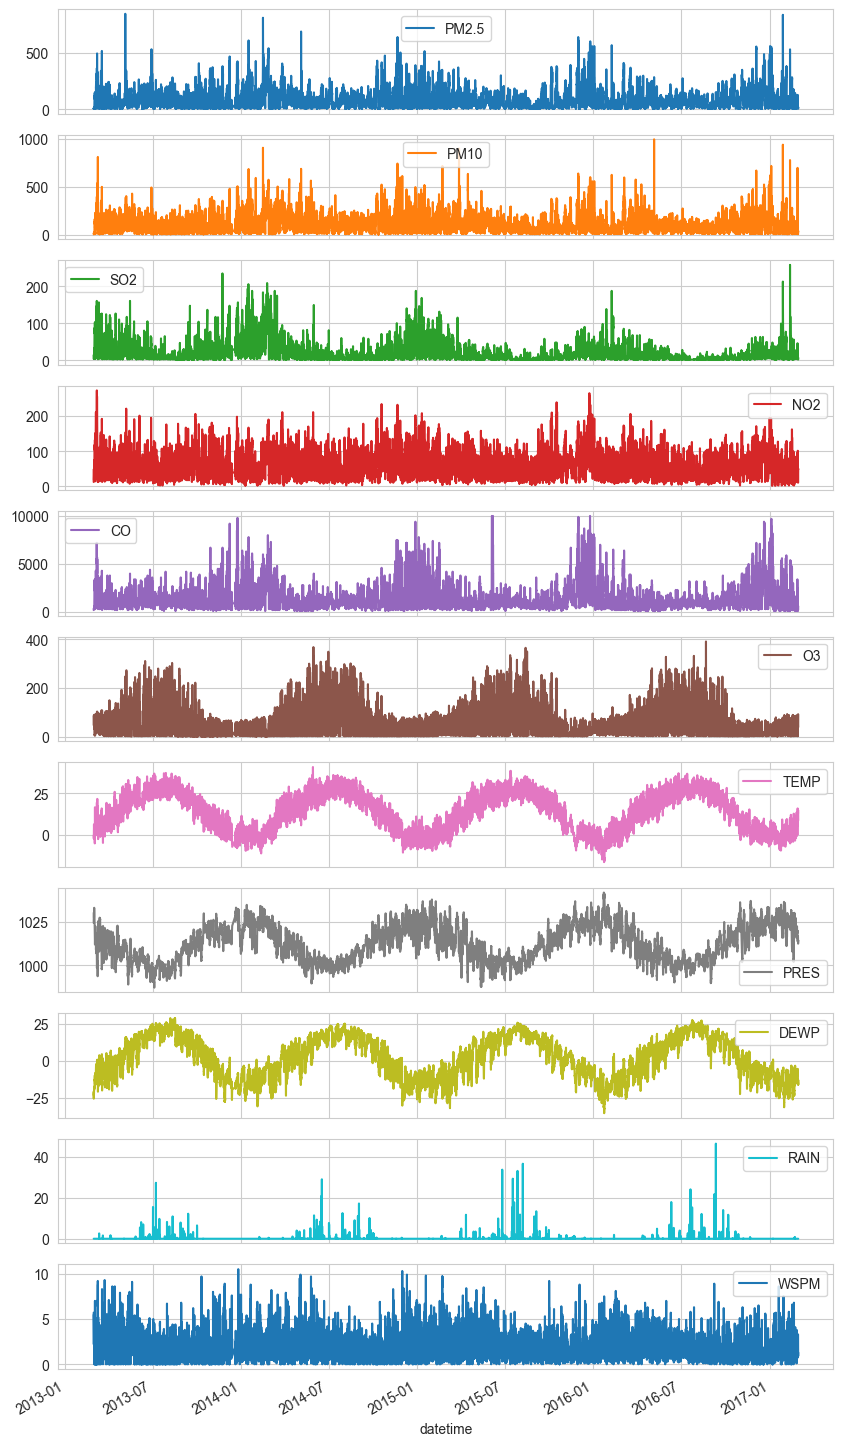

In [20]:
_ = df_daily.plot(subplots=True, figsize=(10, 20))

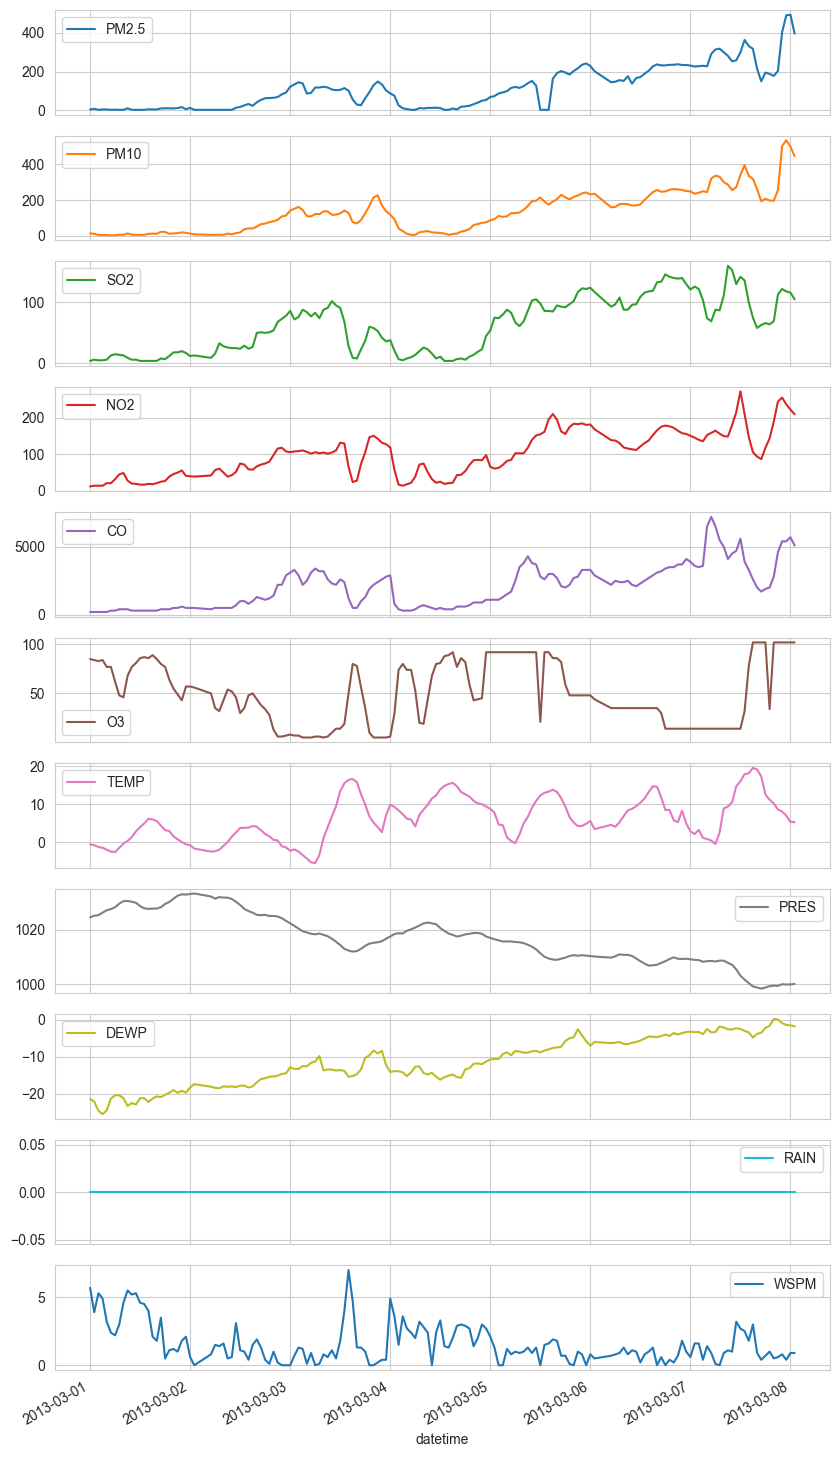

In [21]:
_ = df_daily[:164].plot(subplots=True, figsize=(10, 20))

# Density Distribution

array([<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>], dtype=object)

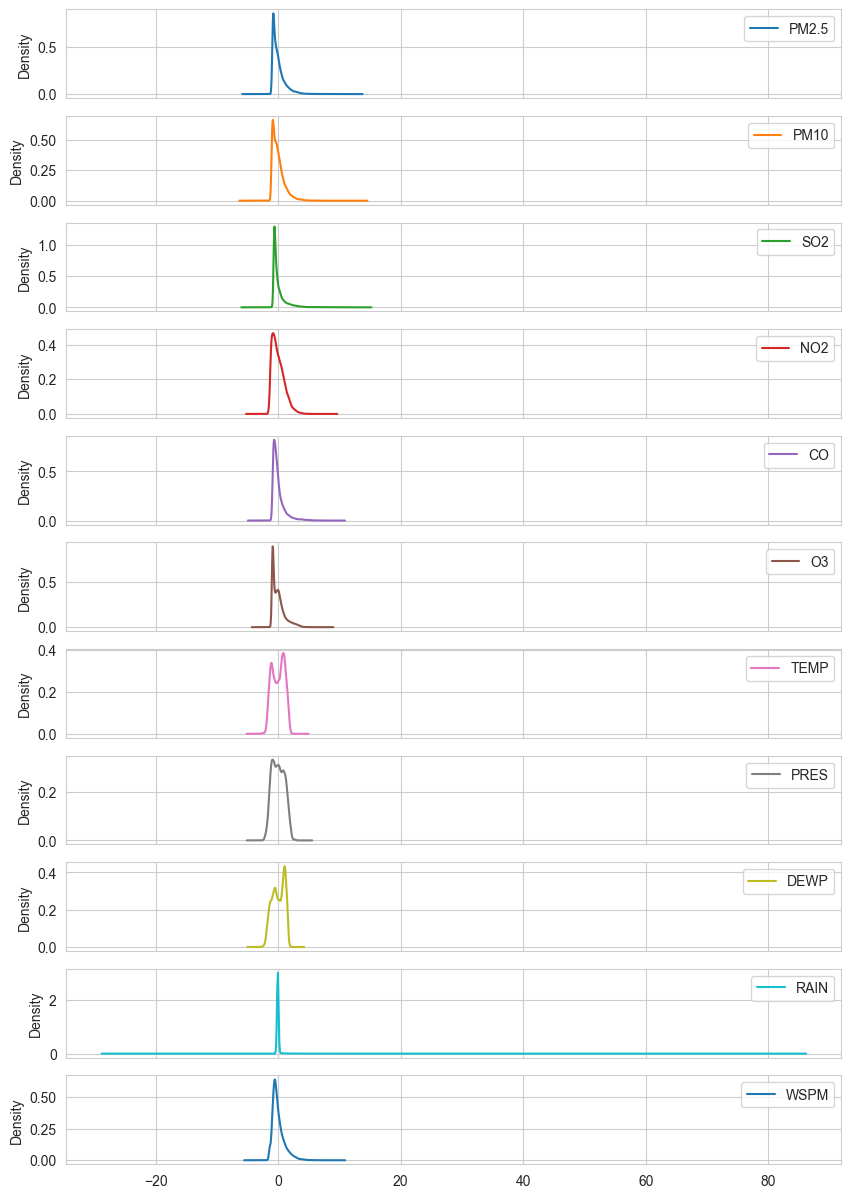

In [22]:
scaler = StandardScaler()
df_daily_scaled  = pd.DataFrame(scaler.fit_transform(df_daily), columns=df_daily.columns.to_list())
df_daily_scaled.plot.kde(subplots=True, figsize=(10, 15))

array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>], dtype=object)

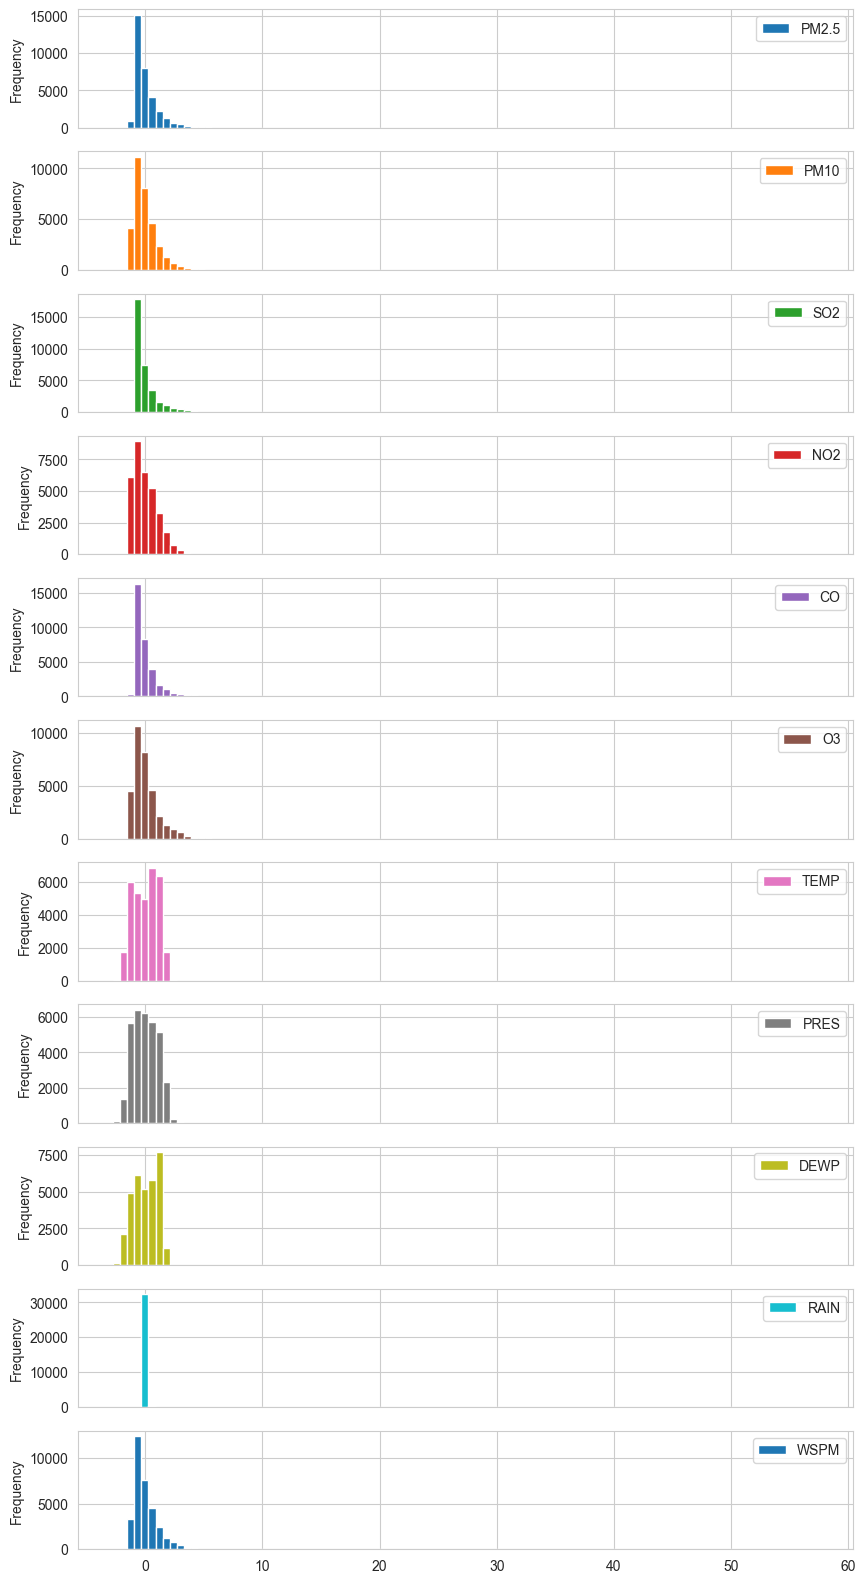

In [23]:
df_daily_scaled.plot.hist(subplots=True, figsize=(10, 20), bins=100)

array([[<Axes: xlabel='PM2.5', ylabel='PM2.5'>,
        <Axes: xlabel='PM10', ylabel='PM2.5'>,
        <Axes: xlabel='SO2', ylabel='PM2.5'>,
        <Axes: xlabel='NO2', ylabel='PM2.5'>,
        <Axes: xlabel='CO', ylabel='PM2.5'>,
        <Axes: xlabel='O3', ylabel='PM2.5'>,
        <Axes: xlabel='TEMP', ylabel='PM2.5'>,
        <Axes: xlabel='PRES', ylabel='PM2.5'>,
        <Axes: xlabel='DEWP', ylabel='PM2.5'>,
        <Axes: xlabel='RAIN', ylabel='PM2.5'>,
        <Axes: xlabel='WSPM', ylabel='PM2.5'>],
       [<Axes: xlabel='PM2.5', ylabel='PM10'>,
        <Axes: xlabel='PM10', ylabel='PM10'>,
        <Axes: xlabel='SO2', ylabel='PM10'>,
        <Axes: xlabel='NO2', ylabel='PM10'>,
        <Axes: xlabel='CO', ylabel='PM10'>,
        <Axes: xlabel='O3', ylabel='PM10'>,
        <Axes: xlabel='TEMP', ylabel='PM10'>,
        <Axes: xlabel='PRES', ylabel='PM10'>,
        <Axes: xlabel='DEWP', ylabel='PM10'>,
        <Axes: xlabel='RAIN', ylabel='PM10'>,
        <Axes: xlabel='WSPM', yl

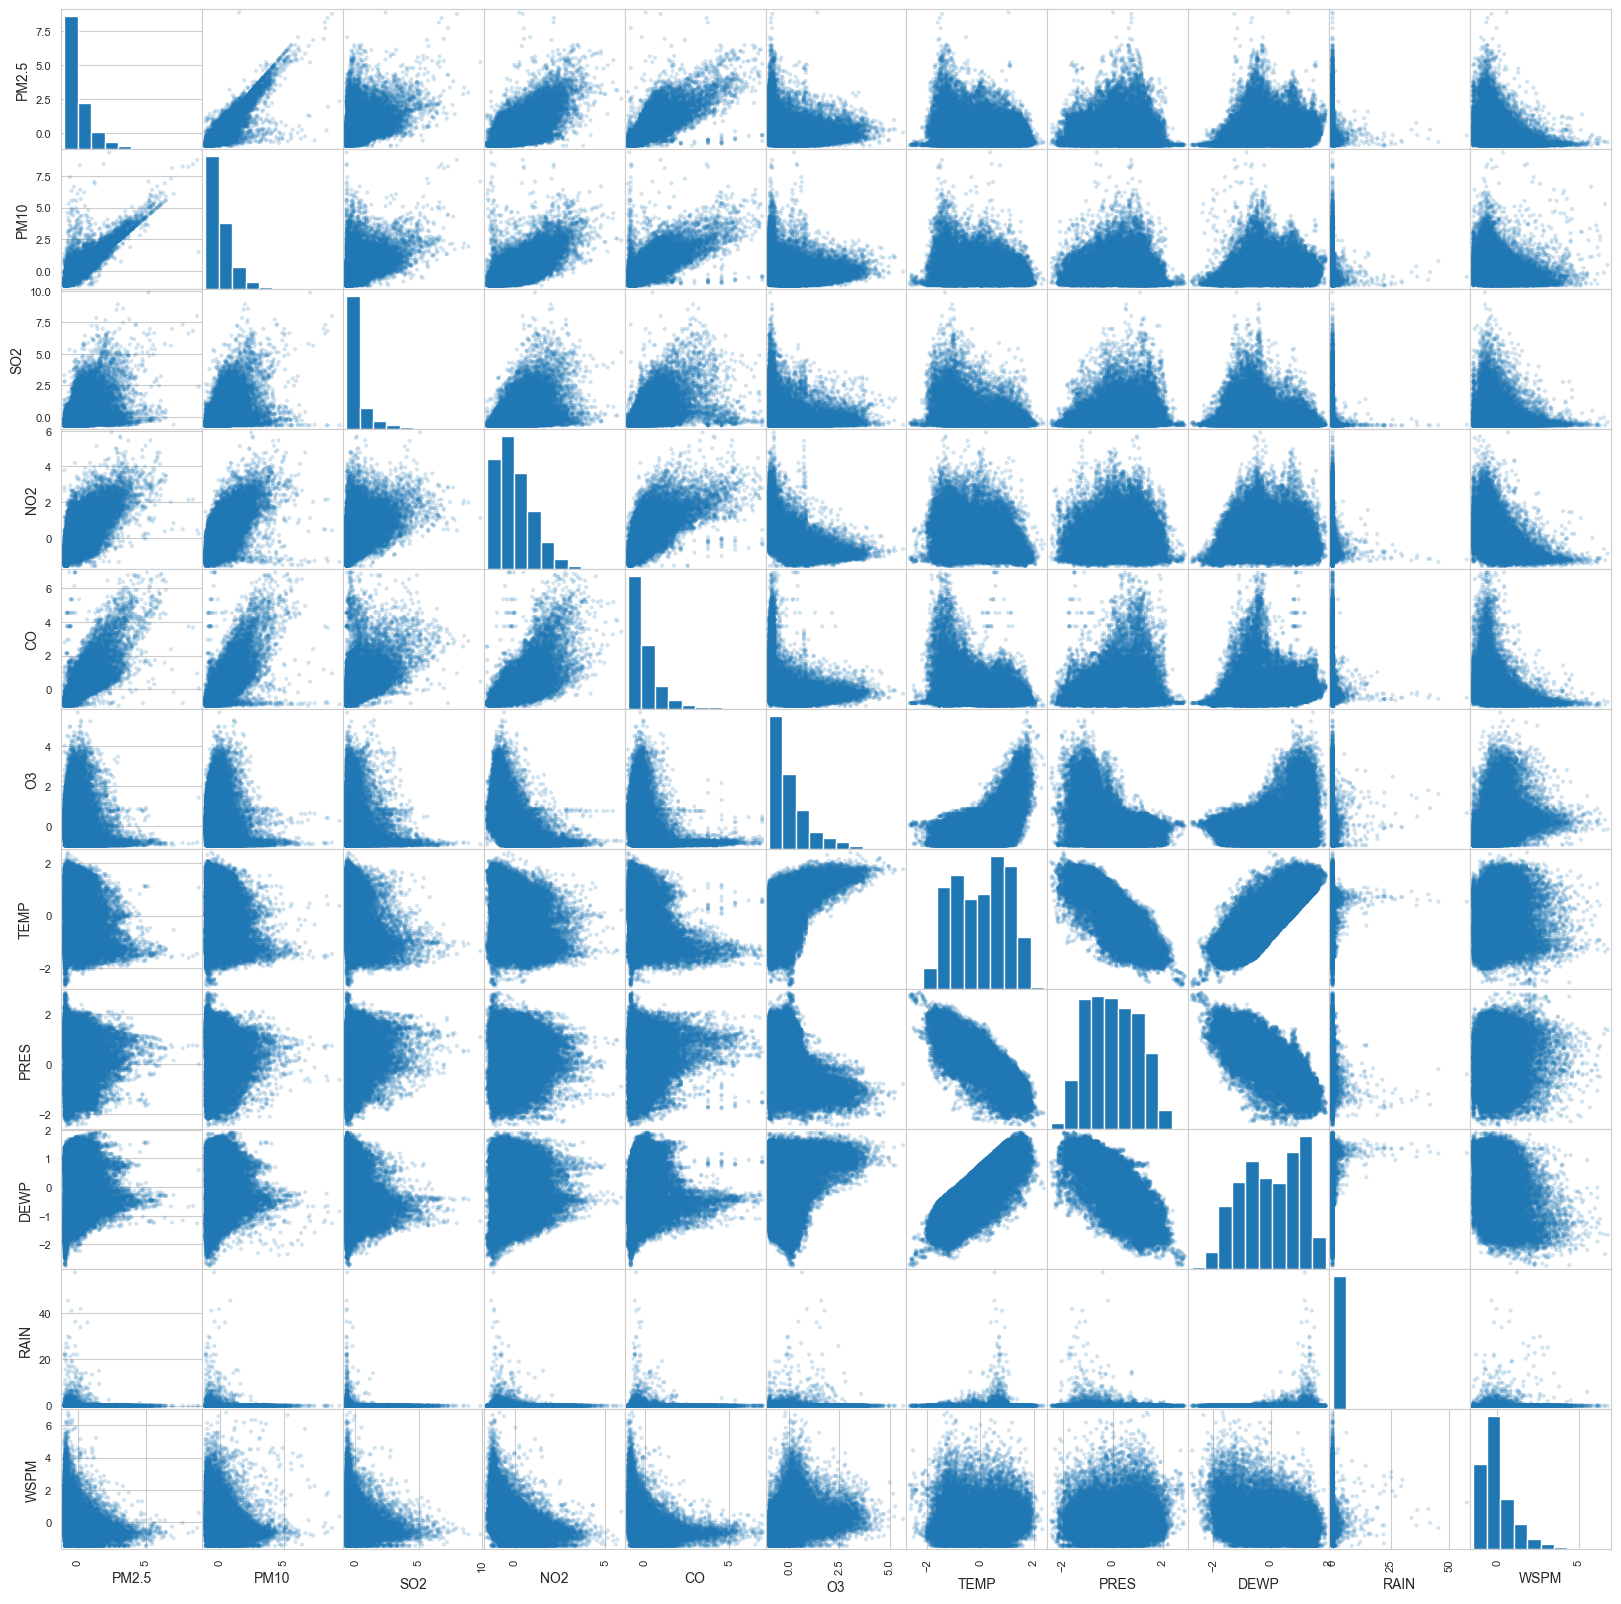

In [24]:
pd.plotting.scatter_matrix(df_daily_scaled, alpha=0.2, figsize=(20, 20))

# Feature Correlation

## Pearson Correlation

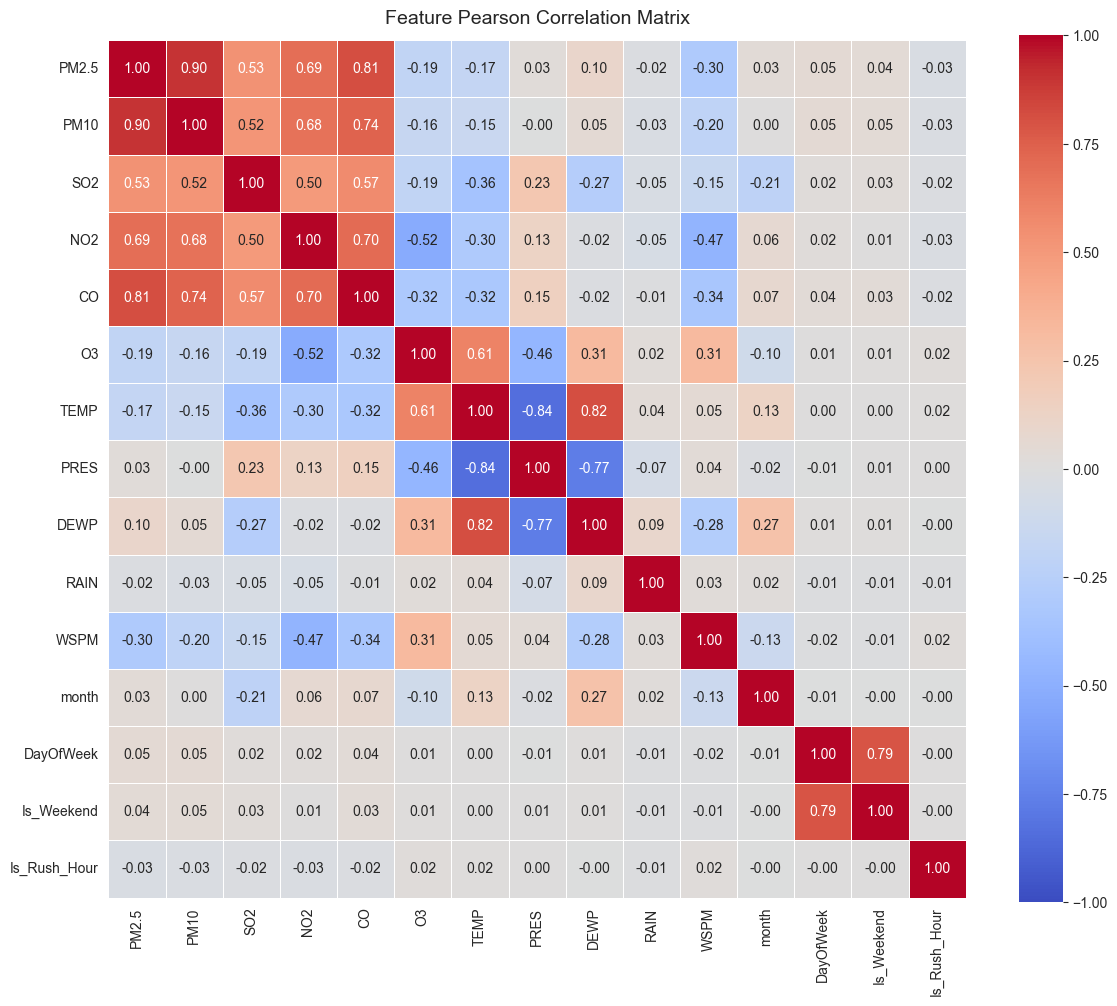

In [25]:
numeric_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'month',
    'DayOfWeek', 'Is_Weekend', 'Is_Rush_Hour'
]

corr_matrix = df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Pearson Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## Spearman Correlation

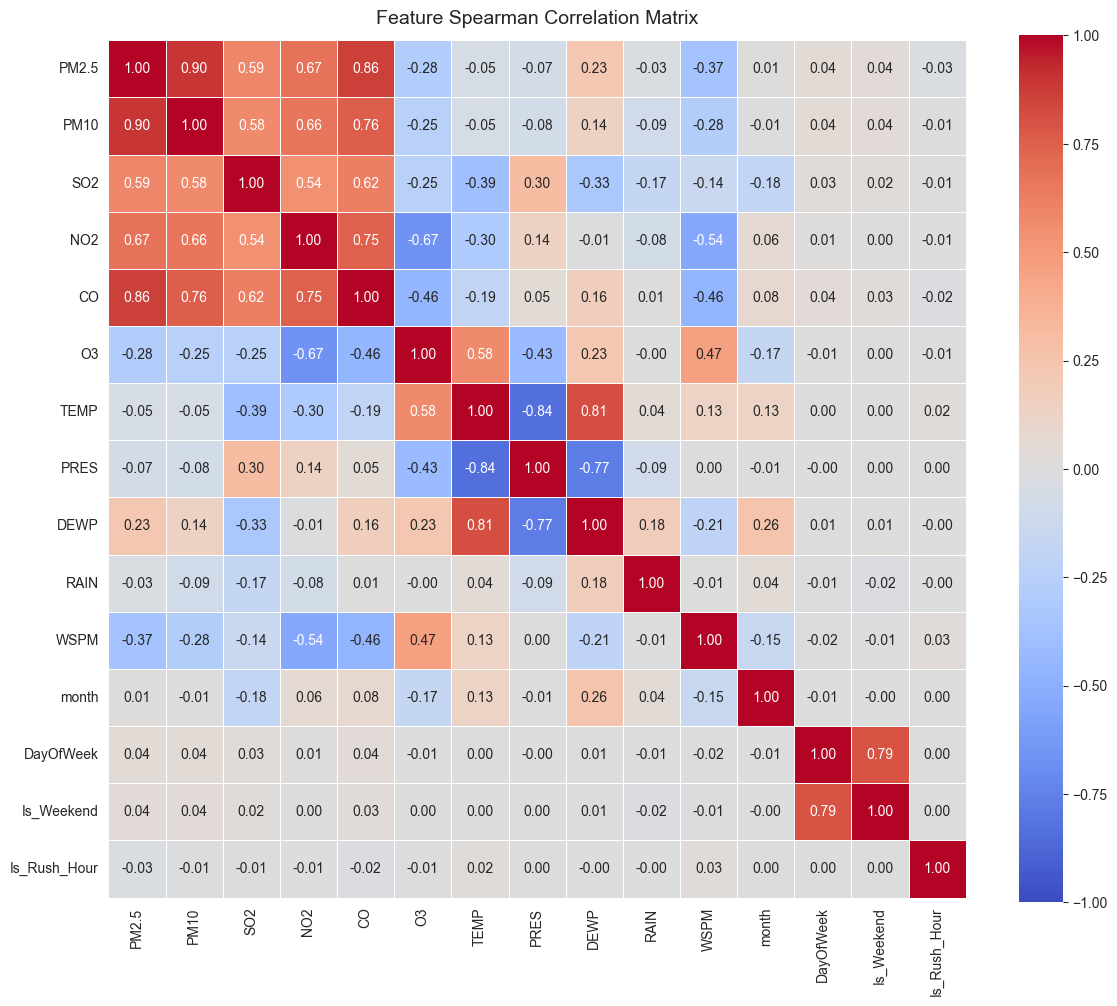

In [26]:
corr_matrix = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Spearman Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Time Series Decomposition


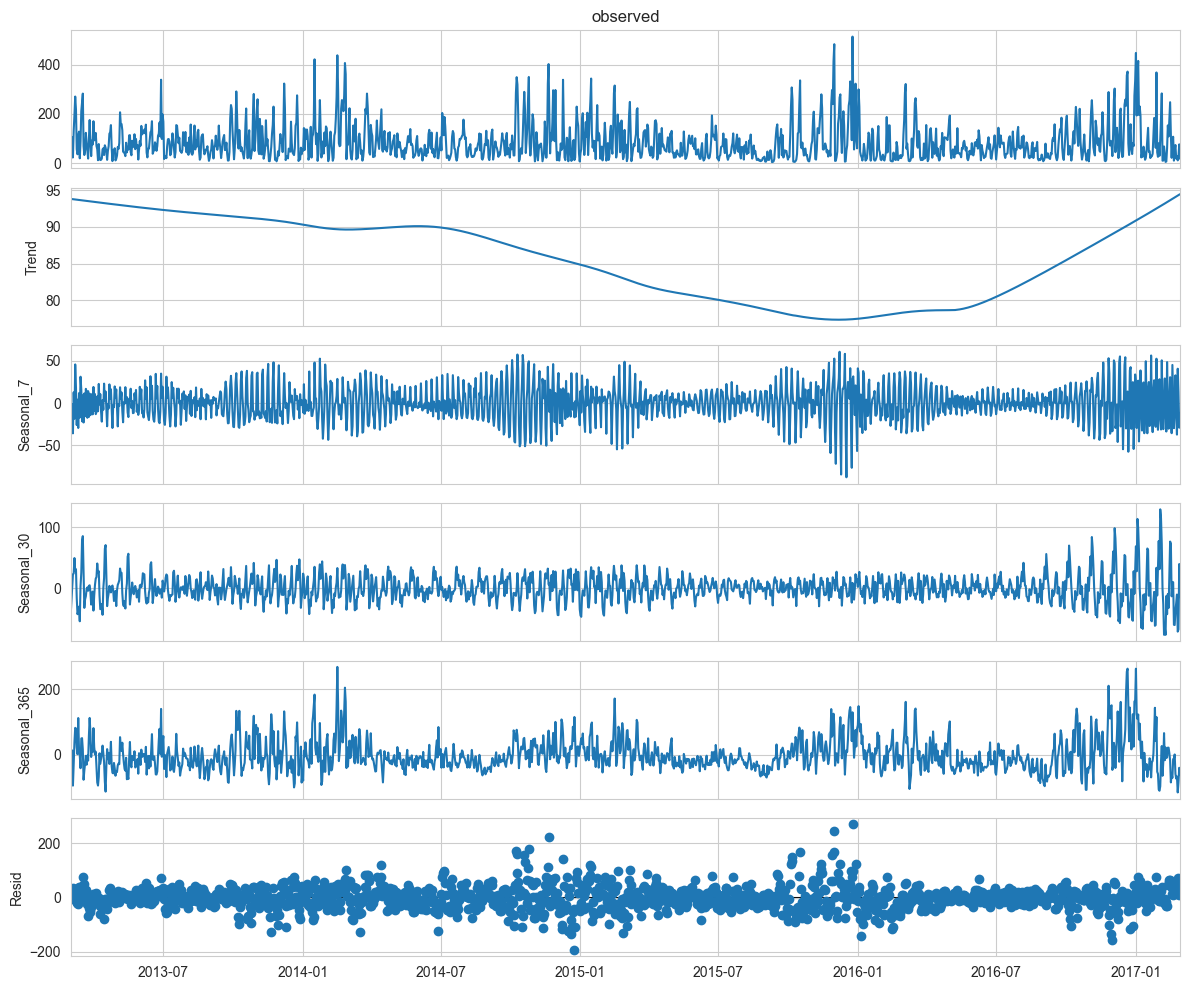

In [27]:
df_single_station = df.copy()
df_single_station.set_index("datetime", inplace=True)
df_daily = df_single_station['PM2.5'].resample('D').mean().dropna()

# Decompose with both monthly (30-day) and yearly (365-day) seasonal components
decomposition = MSTL(df_daily, periods=(7, 30, 365)).fit()

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

# Data Preprocessing

# One-Hot Encoding — Wind Direction

In [28]:
df_encoded = pd.get_dummies(df, columns=['station', 'wd'], drop_first=True)

# Splitting the Data for Training, Test, Validation

the dataset was divided into a training set, test set, and validation set at a ratio of 6:2:2. source: https://www.mdpi.com/2071-1050/14/4/2068

The prediction time units used the multiple air-pollution factor values of the first 8, 16, and 24 h periods to predict the model’s input data. The output results were the PM2.5 concentration data for the next 8 h of the predicted period. source: https://www.mdpi.com/2071-1050/14/4/2068

https://deeplearningwithpython.io/chapters/chapter13_timeseries-forecasting/
https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter13_timeseries-forecasting.ipynb

In [29]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 40 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          35064 non-null  int64         
 1   month         35064 non-null  int64         
 2   day           35064 non-null  int64         
 3   hour          35064 non-null  int64         
 4   PM2.5         34436 non-null  float64       
 5   PM10          34624 non-null  float64       
 6   SO2           34618 non-null  float64       
 7   NO2           34372 non-null  float64       
 8   CO            33858 non-null  float64       
 9   O3            34558 non-null  float64       
 10  TEMP          35044 non-null  float64       
 11  PRES          35044 non-null  float64       
 12  DEWP          35044 non-null  float64       
 13  RAIN          35044 non-null  float64       
 14  WSPM          35050 non-null  float64       
 15  datetime      35064 non-null  dateti

In [30]:
samples = df_encoded.shape[0]

In [31]:
num_train_samples = int(0.5 * samples)
num_val_samples = int(0.25 * samples)
num_test_samples = samples - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 17532
num_val_samples: 8766
num_test_samples: 8766


In [32]:
train_df = df_encoded[:num_train_samples]
val_df = df_encoded[num_train_samples:num_train_samples + num_val_samples]
test_df = df_encoded[num_train_samples + num_val_samples:]

# Impute Missing Values

         KNN MAE  Linear MAE
Gap (h)                     
2         25.700       7.167
6          6.100       7.167
24        23.108      29.632
50        26.797      11.961


/var/folders/28/p99ntdsj0s7_b860_0j_389h0000gn/T/ipykernel_26251/837696222.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gap[col].iloc[s:s+g] = np.nan
/var/folders/28/p99ntdsj0s7_b860_0j_389h0000gn/T/ipykernel_26251/837696222.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gap[col].iloc[s:s+g] = np.nan
/var/folders/28/p99ntdsj0s7_b860_0j_389h0000gn/T/ipykernel_26251/837696222.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versu

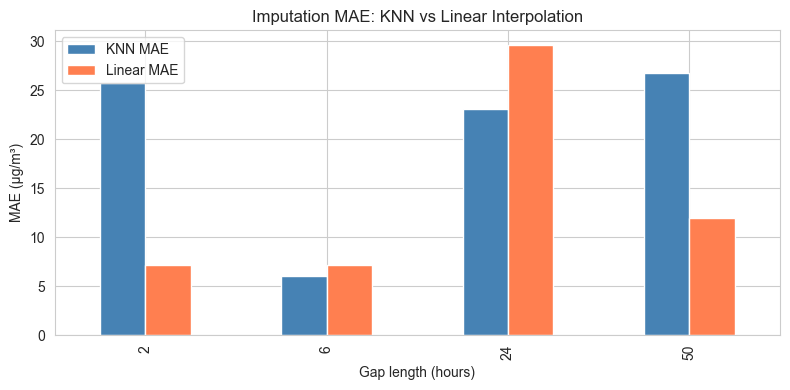


Missing after KNN imputation: 0


In [33]:
def impute_knn(df, k=5):
    num = df.select_dtypes(include=np.number).columns
    out = df.copy()
    out[num] = KNNImputer(n_neighbors=k).fit_transform(df[num])
    return out

def impute_linear(df):
    return df.copy().interpolate(method='linear', limit_direction='both')

def benchmark_imputation(df, col='PM2.5', gap_list=(2, 6, 24, 50), seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for g in gap_list:
        s = rng.integers(100, len(df)-g-100)
        true_vals = df[col].iloc[s:s+g].copy()
        df_gap = df.copy()
        df_gap[col].iloc[s:s+g] = np.nan
        knn_err    = mean_absolute_error(true_vals, impute_knn(df_gap)[col].iloc[s:s+g])
        linear_err = mean_absolute_error(true_vals, impute_linear(df_gap)[col].iloc[s:s+g])
        rows.append({'Gap (h)': g, 'KNN MAE': knn_err, 'Linear MAE': linear_err})
    return pd.DataFrame(rows).set_index('Gap (h)')

bench = benchmark_imputation(train_df.dropna())
print(bench.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
bench.plot.bar(ax=ax, color=['steelblue','coral'], edgecolor='white')
ax.set_title('Imputation MAE: KNN vs Linear Interpolation')
ax.set_xlabel('Gap length (hours)'); ax.set_ylabel('MAE (µg/m³)')
plt.tight_layout(); plt.show()

df_imputed = impute_knn(train_df)
print(f"\nMissing after KNN imputation: {df_imputed.isnull().sum().sum()}")


In [35]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17532 entries, 0 to 17531
Data columns (total 40 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          17532 non-null  float64       
 1   month         17532 non-null  float64       
 2   day           17532 non-null  float64       
 3   hour          17532 non-null  float64       
 4   PM2.5         17532 non-null  float64       
 5   PM10          17532 non-null  float64       
 6   SO2           17532 non-null  float64       
 7   NO2           17532 non-null  float64       
 8   CO            17532 non-null  float64       
 9   O3            17532 non-null  float64       
 10  TEMP          17532 non-null  float64       
 11  PRES          17532 non-null  float64       
 12  DEWP          17532 non-null  float64       
 13  RAIN          17532 non-null  float64       
 14  WSPM          17532 non-null  float64       
 15  datetime      17532 non-null  dateti

# Extreme Values

The processing of extreme values is also crucial. For example, when collecting data from sensors, some natural disasters and human factors might cause errors in the data sensors’ collection. Suppose these extreme values are put into the neural network for training together with the dataset. In that case, it will render the machine learning process with the wrong features, thus resulting in poor prediction performance. Therefore, to avoid the adverse effects of extreme values on machine learning training, the extreme values of the dataset were **deleted by observing each data in the dataset and setting the maximum and minimum values.** If the value in the dataset exceeds the setting value, the record will be flagged.

Winsorizing- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mstats.winsorize.html

Source: https://www.mdpi.com/2071-1050/14/4/2068

In [36]:
def flag_extremes_3sigma(df, features, group_by='station'):
    """
    Flags extreme values using the 3σ method per station.
    Retains data within (μ - 3σ, μ + 3σ), lower limit clipped to 0.
    Returns the cleaned df and a summary of flagged records.
    """
    df = df.copy()
    summary = []

    for feature in features:
        lower_col = f'{feature}_lower'
        upper_col = f'{feature}_upper'
        flag_col  = f'{feature}_extreme'

        # Compute μ and σ per station
        stats = df[feature].agg(['mean', 'std'])
        print(stats.info())
        df = df.join(stats, rsuffix='_stat')

        df[lower_col] = (df['mean'] - 3 * df['std']).clip(lower=0)  # floor at 0
        df[upper_col] =  df['mean'] + 3 * df['std']

        # Flag extremes
        df[flag_col] = (
            (df[feature] < df[lower_col]) |
            (df[feature] > df[upper_col])
        )

        n_flagged = df[flag_col].sum()
        pct       = 100 * n_flagged / len(df)
        summary.append({
            'Feature':   feature,
            'μ (global)': df[feature].mean(),
            'σ (global)': df[feature].std(),
            'Lower limit': df[lower_col].mean(),
            'Upper limit': df[upper_col].mean(),
            'Flagged':    n_flagged,
            'Flagged (%)': pct,
        })

        df.drop(columns=['mean', 'std'], inplace=True)

    return df, pd.DataFrame(summary).set_index('Feature')


# ── Apply ─────────────────────────────────────────────────────────────────────
POLLUTANTS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

df_flagged, extreme_summary = flag_extremes_3sigma(df_imputed, POLLUTANTS)

print("Extreme Value Summary (3σ method):")
print(extreme_summary.to_string(float_format='{:.2f}'.format))


<class 'pandas.core.series.Series'>
Index: 2 entries, mean to std
Series name: PM2.5
Non-Null Count  Dtype  
--------------  -----  
2 non-null      float64
dtypes: float64(1)
memory usage: 32.0+ bytes
None


KeyError: 'mean'

In [ ]:
# ── Remove flagged rows ───────────────────────────────────────────────────────
flag_cols   = [f'{f}_extreme' for f in POLLUTANTS]
any_extreme = df[flag_cols].any(axis=1)

print(f"\nTotal rows flagged (any feature): {any_extreme.sum()} "
      f"({100 * any_extreme.mean():.2f}%)")

df_clean = df[~any_extreme].copy()
print(f"Rows remaining after removal:     {len(df_clean)}")

In [ ]:
# ── Plot — replicates Figure 4 from the paper ─────────────────────────────────
fig, axes = plt.subplots(len(POLLUTANTS), 1, figsize=(14, 4 * len(POLLUTANTS)))

for ax, feature in zip(axes, POLLUTANTS):
    station_df = df[df['station'] == 'Aotizhongxin'].copy()

    upper = station_df[f'{feature}_upper']
    lower = station_df[f'{feature}_lower']
    flags = station_df[f'{feature}_extreme']

    x = range(len(station_df))

    # Raw data — green polyline (matches paper)
    ax.plot(x, station_df[feature], color='green', linewidth=0.6,
            alpha=0.7, label=feature)

    # Upper limit — blue line (matches paper)
    ax.plot(x, upper, color='blue', linewidth=1.2,
            linestyle='--', label='Upper limit (μ + 3σ)')
    ax.plot(x, lower, color='orange', linewidth=1.2,
            linestyle='--', label='Lower limit (max(0, μ − 3σ))')

    # Highlight flagged points in red
    ax.scatter(
        [i for i, f in enumerate(flags) if f],
        station_df.loc[flags, feature],
        color='red', s=10, zorder=5, label='Extreme value'
    )

    ax.set_title(f'{feature} — Extreme Value Detection (3σ) · Aotizhongxin')
    ax.set_xlabel('Record index')
    ax.set_ylabel(feature)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Using Winsorizing to Replace Outliers

### Do I need to keep these features are not?

In [ ]:
# df_clean.drop(df_clean.filter(regex='_lower|_upper|_extreme').columns, axis=1, inplace=True)

# Normalisation

In [ ]:
TARGET       = 'PM2.5'
FEATURE_COLS = [c for c in df_imputed.columns if c != TARGET]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(df_imputed[FEATURE_COLS].values)
y_scaled = scaler_y.fit_transform(df_imputed[[TARGET]].values)

df_norm = pd.DataFrame(
    np.hstack([X_scaled, y_scaled]),
    columns=FEATURE_COLS + [TARGET],
    index=df_imputed.index)
print("Normalised value ranges (sample cols):")
df_norm[['CO','NO2','PM10','PM2.5']].describe().round(3)


# Cross Validation: Create Sequences for Deep Learning

In [ ]:
sampling_rate = 1 # Observations will be sampled at every data point one per hour
sequence_length = 24 * 7 #  Observations will go back seven days (168 hours).
delay = sampling_rate * (sequence_length + 24 - 1) # The target for a sequence will be the PM2.5 24 hours after the end of the sequence.
batch_size = 256

In [ ]:
import keras

train_dataset = keras.utils.timeseries_dataset_from_array(
    df_imputed[:-delay],
    targets=df_imputed['PM2.5'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    # start_index=0,
    # end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    df[:-delay],
    targets=df['PM2.5'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    # start_index=0,
    # end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    df[:-delay],
    targets=df['PM2.5'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    # batch_size=batch_size,
    # start_index=num_train_samples + num_val_samples,
)

# Baseline Models

## Naive Forecast, Moving Average Forecast, Seasonal Naive Forecast

In [ ]:
grouped = df['PM2.5']

# 1. Naive Forecast (Shift by 1 hour, grouped by station)
df['Naive_Forecast'] = grouped.shift(1)

# 2. Moving Average Forecast (3-hour rolling average, grouped by station)
df['Moving_Avg_Forecast'] = grouped.transform(lambda x: x.rolling(window=3).mean().shift(1))

# 3. Seasonal Naive Forecast (Shift by 24 hours, grouped by station)
df['Seasonal_Naive_Forecast'] = grouped.shift(24)

df_all['Is_Hazardous'] = (df_all['PM2.5'] > 75).astype(int)
df_all['Naive_Is_Hazardous'] = (df_all['Naive_Forecast'] > 75).astype(int)
df_all['Moving_Avg_Is_Hazardous'] = (df_all['Moving_Avg_Forecast'] > 75).astype(int)
df_all['Seasonal_Naive_Is_Hazardous'] = (df_all['Seasonal_Naive_Forecast'] > 75).astype(int)

In [ ]:
# 1. Isolate one station and make sure it's sorted chronologically
df_station = df[df['station'] == 'Aotizhongxin'].copy()
df_station = df_station.sort_values('datetime').reset_index(drop=True)

# 2. Set up lists to store the MAE for each horizon (1 to 24)
horizons = range(1, 25)
mae_naive, mae_ma, mae_seasonal = [], [], []

# 3. Loop through each hour in the future
for h in horizons:

    # The Ground Truth: Shift the PM2.5 column UP by 'h' rows to represent the future
    y_true = df_station['PM2.5'].shift(-h)

    # Baseline 1: Naive (Predict the current hour's value for the future)
    y_pred_naive = df_station['PM2.5']

    # Baseline 2: 3-Hour Moving Average (Predict the current average for the future)
    y_pred_ma = df_station['PM2.5'].rolling(window=3).mean()

    # Baseline 3: Seasonal Naive
    # To predict 'h' hours ahead, we look at what happened exactly 24 hours before that target time.
    y_pred_seasonal = df_station['PM2.5'].shift(24 - h)

    # Create a temporary dataframe to easily drop NAs created by all the shifting
    temp_df = pd.DataFrame({
        'True': y_true,
        'Naive': y_pred_naive,
        'MA': y_pred_ma,
        'Seasonal': y_pred_seasonal
    }).dropna()

    # Calculate and store the MAE for this specific horizon
    mae_naive.append(mean_absolute_error(temp_df['True'], temp_df['Naive']))
    mae_ma.append(mean_absolute_error(temp_df['True'], temp_df['MA']))
    mae_seasonal.append(mean_absolute_error(temp_df['True'], temp_df['Seasonal']))

    # (Optional: You could do the exact same thing here using mean_squared_error
    # wrapped in np.sqrt() to store RMSE!)

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the three error curves
plt.plot(horizons, mae_naive, label='Naïve Forecast', marker='o', color='gray')
plt.plot(horizons, mae_ma, label='3-hr Moving Average', marker='s', color='orange')
plt.plot(horizons, mae_seasonal, label='Seasonal Naïve (24hr cycle)', marker='^', color='green')

# Format the chart
plt.title('Baseline Forecast Degradation: 1-Hour to 24-Hour Horizon')
plt.xlabel('Forecast Horizon (Hours Ahead)')
plt.ylabel('Mean Absolute Error (µg/m³) - Lower is Better')
plt.xticks(horizons) # Force it to show 1 through 24 on the x-axis
plt.legend()
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
df_station

## StatsForecast Models

In [ ]:
from statsforecast import StatsForecast

horizon = 24 # 24 hour period

models = [Naive(), HistoricAverage(), WindowAverage(window_size=24), SeasonalNaive(season_length=24)]

sf = StatsForecast(models=models, freq='h')
sf.fit(df_station, id_col="station", time_col='datetime', target_col="PM2.5")
preds = sf.predict(h=horizon)

In [ ]:
preds.head()

In [ ]:
plot_series(df_station, forecasts_df=preds, max_insample_length=24, id_col="station", time_col='datetime', target_col="PM2.5")

In [ ]:
categorical_columns = df.columns[df.dtypes == "category"]
print("Categorical features:", categorical_columns.tolist())

In [ ]:
columns_to_drop = [col for col in df.columns.to_list() if col not in ["PM2.5", "station", "datetime"]]

In [ ]:
test = df.drop(columns_to_drop, axis=1).groupby("station").tail(24)
train = df.drop(columns_to_drop, axis=1).drop(test.index).reset_index(drop=True)

In [ ]:
sf.fit(df=train, id_col="station", time_col='datetime', target_col="PM2.5")

preds = sf.predict(h=horizon)

eval_df = pd.merge(test, preds, 'left', ['station', 'datetime'])

In [ ]:
from utilsforecast.losses import mae
from utilsforecast.evaluation import evaluate

evaluation = evaluate(
    eval_df,
    metrics=[mae],
    id_col="station", time_col='datetime', target_col="PM2.5"
)
evaluation.head()

In [ ]:
evaluation = evaluation.drop(['station'], axis=1).groupby('metric').mean().reset_index()

In [ ]:
evaluation

In [ ]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

# Time-based Cross-Validation

In [ ]:
ts_cv = TimeSeriesSplit(
    n_splits=5,
    gap=48,
    max_train_size=10000,
    test_size=1000,
)

# Prep for Training

Rescale the target variable (PM2.5) to predict a relative demand so that the mean absolute error is more easily interpreted as a fraction of the maximum demand.

Note

The fit method of the models used in this notebook all minimizes the mean squared error to estimate the conditional mean. The absolute error, however, would estimate the conditional median.

Nevertheless, when reporting performance measures on the test set in the discussion, we choose to focus on the mean absolute error instead of the (root) mean squared error because it is more intuitive to interpret. Note, however, that in this study the best models for one metric are also the best ones in terms of the other metric.

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html


In [ ]:
df_clean.info()

In [ ]:
# 1 & 2: Drop columns the model shouldn't see
columns_to_drop = ['datetime', 'Naive_Forecast', 'Moving_Avg_Forecast', 'Seasonal_Naive_Forecast']
                   # 'Is_Hazardous', 'Naive_Is_Hazardous', 'Moving_Avg_Is_Hazardous', 'Seasonal_Naive_Is_Hazardous']
df_model_ready = df_clean.drop(columns=columns_to_drop)
df_model_ready.drop(df_model_ready.filter(regex='_lower|_upper|_extreme|lag').columns, axis=1, inplace=True)

In [ ]:
df_model_ready.info()

# One-Hot Encoding for Wind Direction and Station + X & y

In [ ]:
# 3: Convert text categories (Station Name and Wind Direction) into numbers
X = pd.get_dummies(df_model_ready, columns=['station', 'wd'], drop_first=True)
y = df_model_ready['PM2.5'] # / df["PM2.5"].max()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
y.hist(bins=30, ax=ax)
_ = ax.set(
    xlabel="Fraction of PM2.5",
    ylabel="Number of hours",
)

# Dimensionality Reduction

In [ ]:
# T-SNE Implementation
# X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)

In [ ]:
# PCA Implementation
X_reduced_pca = PCA(n_components=len(df.columns.to_list()), random_state=69420).fit_transform(X.values)

In [ ]:
# TruncatedSVD
X_reduced_svd = TruncatedSVD(n_components=len(df.columns.to_list()), algorithm='randomized', random_state=69420).fit_transform(X.values)

In [ ]:
f, (ax2, ax3) = plt.subplots(1, 2, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpl.patches.Patch(color='#0A0AFF', label='No Ransom')
red_patch = mpl.patches.Patch(color='#AF0000', label='Ransom')


# t-SNE scatter plot
# ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Ransom', linewidths=2)
# ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Ransom', linewidths=2)
# ax1.set_title('t-SNE', fontsize=14)

# ax1.grid(True)

# ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', linewidths=2)
# ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=y, cmap='coolwarm', label='Ransom', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', linewidths=2)
# ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Ransom', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

# Time Lag Experiment

In [ ]:
from scipy.stats import pearsonr
import warnings

# ── Config ────────────────────────────────────────────────────────────────────
TARGET    = 'PM2.5'                        # correlate against raw PM2.5
LAG_RANGE = range(1, 49)                   # test lags 1h → 48h
FEATURES  = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
             'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


In [ ]:
# ── 1. Compute Pearson r at each lag for each feature ─────────────────────────
# Work on a single station to keep temporal ordering clean
df_station = df.copy()

results = []

for feature in FEATURES:
    for lag in LAG_RANGE:
        lagged  = df_station[feature].shift(lag)       # feature at time t-lag
        target  = df_station[TARGET]                   # PM2.5 at time t

        # Drop NaNs introduced by shift
        valid   = pd.concat([lagged, target], axis=1).dropna()

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r, p = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])

        results.append({
            'Feature': feature,
            'Lag (hours)': lag,
            'Pearson r': r,
            'p-value': p,
            'Significant': p < 0.05
        })

results_df = pd.DataFrame(results)


In [ ]:
# ── 2. Find optimal lag per feature (highest |r|) ─────────────────────────────
best_lags = (
    results_df.loc[results_df.groupby('Feature')['Pearson r']
                              .apply(lambda x: x.abs().idxmax())]
    .sort_values('Pearson r', ascending=False)
    .reset_index(drop=True)
)
print("Optimal lag per feature:")
print(best_lags[['Feature', 'Lag (hours)', 'Pearson r', 'p-value']].to_string(index=False))


In [ ]:
# ── 3. Heatmap — Pearson r across all features and lags ──────────────────────
pivot = results_df.pivot(index='Feature', columns='Lag (hours)', values='Pearson r')

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    pivot,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.2, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title(f'Time-Lag Correlation with {TARGET} — Aotizhongxin Station')
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
# ── 4. Line plot — correlation decay curves per feature ──────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
for feature in FEATURES:
    subset = results_df[results_df['Feature'] == feature]
    ax.plot(subset['Lag (hours)'], subset['Pearson r'], label=feature, linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Pearson r')
ax.set_title(f'Correlation Decay Curves — Feature vs {TARGET} at Increasing Lags')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ── 5. (Optional) Add optimal lag features back to the model ─────────────────
for _, row in best_lags.iterrows():
    feat    = row['Feature']
    optimal = int(row['Lag (hours)'])
    col     = f"{feat}_lag{optimal}"
    df[col] = df.groupby('station')[feat].shift(optimal)
    print(f"Added: {col}  (r={row['Pearson r']:.3f})")

## Pearson Correlation

## Spearman Correlation

# Feature Engineering

In [ ]:
categorical_columns = df.columns[df.dtypes == "category"]
print("Categorical features:", categorical_columns.tolist())

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV


alphas = np.logspace(-6, 6, 25)

cyclic_cossin_transformer = ColumnTransformer(
    transformers=[
        ("categorical", one_hot_encoder, categorical_columns),
        ("month_sin", sin_transformer(12), ["month"]),
        ("month_cos", cos_transformer(12), ["month"]),
        ("weekday_sin", sin_transformer(7), ["DayOfWeek"]),
        ("weekday_cos", cos_transformer(7), ["DayOfWeek"]),
        ("hour_sin", sin_transformer(24), ["hour"]),
        ("hour_cos", cos_transformer(24), ["hour"]),
    ],
    remainder=MinMaxScaler(),
)

cyclic_cossin_linear_pipeline = make_pipeline(
    # cyclic_cossin_transformer,
    RidgeCV(alphas=alphas),
)

tempX = df_model_ready[df_model_ready['station'] == 'Aotizhongxin'].copy()
tempy = tempX['PM2.5']

sklearnEvaluate(cyclic_cossin_linear_pipeline, tempX, tempy, cv=ts_cv)

## Scale/Normalize The Data

https://www.tensorflow.org/tutorials/structured_data/time_series#normalize_the_data

In [ ]:
def plotViolin(df, train_mean, train_std):
    df_std = (df - train_mean) / train_std
    df_std = df_std.melt(var_name='Column', value_name='Normalized')
    plt.figure(figsize=(12, 6))
    ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
    _ = ax.set_xticklabels(df.keys(), rotation=90)


In [ ]:
def standardScale(x_train, x_test, y_train, y_test, df):
    train_mean = x_train.mean()
    train_std = x_train.std()

    X_train_scaled = (x_train - train_mean) / train_std
    # val_df = (val_df - train_mean) / train_std
    X_test_scaled = (x_test - train_mean) / train_std

    y_train_array = y_train.values
    y_test_array = y_test.values

    # plotViolin(df, train_mean, train_std)

    return X_train_scaled, X_test_scaled, y_train_array, y_test_array

In [ ]:
def minMaxScale(X_train, X_test, y_train, y_test, df):
    train_mean = X_train.mean()
    train_std = X_train.std()

    X_train_scaled = (X_train - train_mean) / train_std
    # val_df = (val_df - train_mean) / train_std
    X_test_scaled = (X_test - train_mean) / train_std

    y_train_array = y_train.values
    y_test_array = y_test.values

    # plotViolin(df, train_mean, train_std)

    return X_train_scaled, X_test_scaled, y_train_array, y_test_array

# Histogram-based Gradient Boosting Regression Tree

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#gradient-boosting

In [ ]:
gbrt = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=42)

In [ ]:
sklearnEvaluate(gbrt, X, y, cv=ts_cv, model_prop="n_iter_")

# Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

In [ ]:
sklearnEvaluate(rf_model, X, y, cv=ts_cv)

# Normalization using Vectorization

# Deep Learning

# RNN, LSTM, CNN

In [ ]:
X.info()

In [ ]:
WINDOW     = 24   # use the past 24 hours as context
THRESHOLD  = 75
BATCH_SIZE = 256
EPOCHS     = 30

# ── 2. Scale features (required for neural nets) ─────────────────────────────
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)


In [ ]:
# ── 3. Build sliding windows ──────────────────────────────────────────────────
# Each sample becomes a (WINDOW, n_features) sequence
def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])   # shape: (window, n_features)
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y, WINDOW)
# X_seq shape: (n_samples, 24, n_features)

n_steps    = X_seq.shape[1]
n_features = X_seq.shape[2]

print("n_steps:", n_steps)
print("n_features:", n_features)

In [ ]:
# ── 4. Model definitions ──────────────────────────────────────────────────────
def build_rnn():
    m = Sequential()
    m.add(Input(shape=(n_steps, n_features)))
    m.add(SimpleRNN(64, return_sequences=False))
    m.add(Dropout(0.2))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

def build_lstm():
    m = Sequential()
    m.add(Input(shape=(n_steps, n_features)))
    m.add(LSTM(64, return_sequences=False))
    m.add(Dropout(0.2))
    m.add(Dense(1, activation='sigmoid'))

    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

def build_cnn():
    m = Sequential()
    m.add(Input(shape=(n_steps, n_features)))
    m.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    m.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    m.add(GlobalMaxPooling1D())
    m.add(Dropout(0.2))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

builders = {
    'RNN':  build_rnn,
    'LSTM': build_lstm,
    'CNN':  build_cnn,
}

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:
# ── 5. Time-series CV ─────────────────────────────────────────────────────────
metric_keys = ['MAE', 'MSE', 'RMSE']
nn_metrics = {name: {m: [] for m in metric_keys} for name in builders}

for fold, (train_idx, test_idx) in enumerate(ts_cv.split(X_seq, y_seq), start=1):
    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_seq[train_idx], y_seq[test_idx]

    fold_summary = f"Fold {fold}"

    for name, build_fn in builders.items():
        model = build_fn()   # fresh model each fold
        print(model.summary())
        history = model.fit(
            X_train, y_train,
            validation_split=0.1,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0
        )

        y_prob = model.predict(X_test, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)

        nn_metrics[name]['MAE'].append(mean_absolute_error(y_test, y_pred))
        nn_metrics[name]['MSE'].append(mean_squared_error(y_test, y_pred))
        nn_metrics[name]['RMSE'].append(root_mean_squared_error(y_test, y_pred))

        fold_summary += f" | {name} MAE: {nn_metrics[name]['MAE'][-1]:.3f}"
        fold_summary += f" | {name} MSE: {nn_metrics[name]['MSE'][-1]:.3f}"
        fold_summary += f" | {name} RMSE: {nn_metrics[name]['RMSE'][-1]:.3f}"
        fold_summary += '\n'

    print(fold_summary)


In [ ]:
# ── 6. Merge with existing results and plot ───────────────────────────────────
nn_results_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in metrics.items()}
    for name, metrics in nn_metrics.items()
}).T

all_results_df = pd.concat([results_df, nn_results_df]).sort_values('M', ascending=False)

print("\nFull model comparison:")
print(all_results_df.to_string(float_format='{:.3f}'.format))

all_results_df.plot(kind='bar', figsize=(12, 5), ylim=(0, 1), rot=20)
plt.title('All Models — 24h Ahead Forecast (Time-Series CV)')
plt.ylabel('Score (averaged across folds)')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Overfitting

In [ ]:
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.layers import BatchNormalization


In [ ]:
# ── Experiment variants ───────────────────────────────────────────────────────
def build_baseline():
    """Large network, no regularization — expected to overfit"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True),
        LSTM(64),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_reduced():
    """Smaller network — fewer parameters = less capacity to memorise"""
    m = Sequential([
        LSTM(32, input_shape=(n_steps, n_features)),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_l1_l2():
    """Full size + L1/L2 weight penalties on LSTM kernel and recurrent kernel"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True,
             kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3),
             recurrent_regularizer=l2(1e-3)),
        LSTM(64,
             kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3)),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_dropout():
    """Full size + dropout on outputs and recurrent connections"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True,
             dropout=0.3,              # drops input/output connections
             recurrent_dropout=0.2),   # drops recurrent connections
        LSTM(64,
             dropout=0.3,
             recurrent_dropout=0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

In [ ]:

variants = {
    'Baseline (no reg)': build_baseline,
    'Reduced Size':      build_reduced,
    'L1 + L2':           build_l1_l2,
    'Dropout':           build_dropout,
}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [ ]:
# ── Run experiment: one fold only for speed, use last fold for fair comparison ─
train_idx, test_idx = list(ts_cv.split(X_seq, y_seq))[-1]   # final fold
X_train_e, X_test_e = X_seq[train_idx], X_seq[test_idx]
y_train_e, y_test_e = y_seq[train_idx], y_seq[test_idx]

histories   = {}
exp_results = {}

for name, build_fn in variants.items():
    print(f"\nTraining: {name}")
    model = build_fn()

    history = model.fit(
        X_train_e, y_train_e,
        validation_split=0.15,
        epochs=60,
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )
    histories[name] = history.history

    y_pred = (model.predict(X_test_e, verbose=0).flatten() > 0.5).astype(int)
    exp_results[name] = {
        'F1':        f1_score(y_test_e, y_pred),
        'Precision': precision_score(y_test_e, y_pred),
        'Recall':    recall_score(y_test_e, y_pred),
        'Accuracy':  accuracy_score(y_test_e, y_pred),
        'Best epoch': len(history.history['loss']),    # epochs before early stop
        'Train loss': min(history.history['loss']),
        'Val loss':   min(history.history['val_loss']),
    }


In [ ]:
# ── Results table ─────────────────────────────────────────────────────────────
exp_df = pd.DataFrame(exp_results).T
print("\nOverfitting Experiment Results:")
print(exp_df.to_string(float_format='{:.3f}'.format))

# ── Plot 1: Train vs Val loss curves (overfitting diagnostic) ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, hist) in zip(axes, histories.items()):
    epochs = range(1, len(hist['loss']) + 1)
    ax.plot(epochs, hist['loss'],     label='Train loss', linewidth=1.8)
    ax.plot(epochs, hist['val_loss'], label='Val loss',   linewidth=1.8, linestyle='--')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

    # Highlight the gap between train and val (overfitting zone)
    ax.fill_between(epochs,
                    hist['loss'], hist['val_loss'],
                    alpha=0.1, color='red', label='Overfit gap')

plt.suptitle('Overfitting Experiment — Train vs Validation Loss', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── Plot 2: F1 comparison bar chart ──────────────────────────────────────────
exp_df[['F1', 'Precision', 'Recall', 'Accuracy']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1), rot=15
)
plt.title('Overfitting Experiment — Test Metrics Comparison')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# ── Plot 3: Overfit gap bar (train loss − val loss per variant) ───────────────
gap = exp_df['Train loss'] - exp_df['Val loss']
gap.sort_values().plot(
    kind='barh', figsize=(8, 4),
    color=['green' if v <= 0 else 'tomato' for v in gap.sort_values()]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Train − Val Loss Gap  (negative = generalising well, positive = overfitting)')
plt.xlabel('Loss gap')
plt.tight_layout()
plt.show()

# Hyper-parameter Training & Selection